# Lizard Species Image Classification Challenge

**Course:** Artificial Intelligence - Thomas More  
**Team members:** `<fill in>`  
**Notebook goal:** build a strong, well-documented TensorFlow/Keras image classifier for 7 lizard species.

## Species
1. Black spiny tailed iguana
2. Brown anole
3. Cuban knight anole
4. Desert iguana
5. Green anole
6. Green iguana
7. Lesser Antillean iguana

## What this notebook covers
- dataset integrity checks and exploratory data analysis
- image quality checks, including duplicate analysis and OCR-style text-overlay checks
- data augmentation
- transfer learning with staged fine-tuning
- training and validation visualisation
- confusion matrix and macro-F1 evaluation
- test-set inference and competition submission export
- a short GenAI reflection section

In [17]:
# Run this once if your environment is still missing packages.
# In Google Colab, use this cell before running the rest of the notebook.
%pip install -q tensorflow pandas numpy matplotlib pillow opencv-python pytesseract openpyxl

# Important:
# `pytesseract` is only the Python wrapper.
# For real OCR extraction you still need the Tesseract engine installed on the machine itself.

Note: you may need to restart the kernel to use updated packages.


## Why this approach?

The dataset is relatively small, so a pure CNN from scratch would likely underperform or overfit quickly.  
Because of that, we combine:

- transfer learning from an ImageNet backbone
- moderate augmentation
- early stopping and learning-rate reduction
- a duplicate-aware validation split to reduce leakage risk
- simple test-time augmentation for a small boost at inference time

The challenge page mentions "probabilities", but the provided sample submission and the macro-F1 scoring setup point to a **single class label per image**.  
We therefore export `ID,TARGET` with integer class predictions.

In [18]:
from pathlib import Path
import math
import shutil
import warnings

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from IPython.display import display
from PIL import Image, ImageOps
from tensorflow import keras
from tensorflow.keras import layers

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    plt.switch_backend("Agg")

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8")

SEED = 42
IMG_SIZE = (260, 260)
BATCH_SIZE = 24
VAL_FRACTION = 0.20
INITIAL_EPOCHS = 8
FINE_TUNE_EPOCHS = 12
FINE_TUNE_LAYERS = 40
USE_TTA = True

keras.utils.set_random_seed(SEED)
AUTOTUNE = tf.data.AUTOTUNE

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

try:
    gpus = tf.config.list_physical_devices("GPU")
    if gpus:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        from tensorflow.keras import mixed_precision
        mixed_precision.set_global_policy("mixed_float16")
        print("Mixed precision enabled.")
    else:
        print("Running on CPU. Training will work, but a GPU or Colab runtime is recommended.")
except Exception as exc:
    print("Could not configure mixed precision:", exc)

TensorFlow: 2.21.0
Keras: 3.14.0
GPU devices: []
Running on CPU. Training will work, but a GPU or Colab runtime is recommended.


In [19]:
def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    candidates = [start, *start.parents]
    required = {"train.csv", "test.csv", "sample_submission.csv", "train", "test"}
    for candidate in candidates:
        names = {path.name for path in candidate.iterdir()} if candidate.exists() else set()
        if required.issubset(names):
            return candidate
    raise FileNotFoundError(
        "Could not find the project root. Start the notebook from the repository or a subfolder of it."
    )

ROOT = find_project_root()
TRAIN_DIR = ROOT / "train"
TEST_DIR = ROOT / "test"
TRAIN_CSV = ROOT / "train.csv"
TEST_CSV = ROOT / "test.csv"
SAMPLE_SUBMISSION = ROOT / "sample_submission.csv"

train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)

filename_to_path = {path.name: path for path in TRAIN_DIR.rglob("*.jpg")}
train_df["path"] = train_df["id"].map(filename_to_path)
assert train_df["path"].notna().all(), "Some train rows could not be matched to image files."

train_df["class_name"] = train_df["path"].map(lambda p: Path(p).parent.name)
label_to_class = (
    train_df[["label", "class_name"]]
    .drop_duplicates()
    .sort_values("label")
    .set_index("label")["class_name"]
    .to_dict()
)
class_to_label = {class_name: label for label, class_name in label_to_class.items()}
class_names = [label_to_class[i] for i in sorted(label_to_class)]
num_classes = len(class_names)

test_df["path"] = test_df["id"].map(lambda image_id: TEST_DIR / f"{image_id}.jpg")
assert test_df["path"].map(lambda p: p.exists()).all(), "Some test rows have no matching image."

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Resolved project root:", ROOT)
print("Label mapping:", label_to_class)
display(train_df.head())

Train shape: (1334, 4)
Test shape: (326, 2)
Resolved project root: C:\TM\2e_jaar\Semester_2\AI\AI-Lizard-Prediction-Challenge
Label mapping: {0: 'Black_spiny_tailed_iguana', 1: 'Brown_anole', 2: 'Cuban_knight_anole', 3: 'Desert_iguana', 4: 'Green_anole', 5: 'Green_iguana', 6: 'Lesser_Antillean_iguana'}


,id,label,path,class_name
0,Black_spiny-tailed_iguana_Black_spiny-tailed_i...,0,C:\TM\2e_jaar\Semester_2\AI\AI-Lizard-Predicti...,Black_spiny_tailed_iguana
1,Black_spiny-tailed_iguana_Black_spiny-tailed_i...,0,C:\TM\2e_jaar\Semester_2\AI\AI-Lizard-Predicti...,Black_spiny_tailed_iguana
2,Black_spiny-tailed_iguana_Black_spiny-tailed_i...,0,C:\TM\2e_jaar\Semester_2\AI\AI-Lizard-Predicti...,Black_spiny_tailed_iguana
3,Black_spiny-tailed_iguana_Black_spiny-tailed_i...,0,C:\TM\2e_jaar\Semester_2\AI\AI-Lizard-Predicti...,Black_spiny_tailed_iguana
4,Black_spiny-tailed_iguana_Black_spiny-tailed_i...,0,C:\TM\2e_jaar\Semester_2\AI\AI-Lizard-Predicti...,Black_spiny_tailed_iguana


## 1. Exploratory Data Analysis

We first verify that the CSV files and image folders are consistent.  
After that we inspect:

- class balance
- image resolution variation
- brightness and blur spread
- near-duplicate groups
- possible text or watermark overlays

,label,class_name,count,share_pct
0,0,Black_spiny_tailed_iguana,199,14.92
1,1,Brown_anole,193,14.47
2,2,Cuban_knight_anole,189,14.17
3,3,Desert_iguana,183,13.72
4,4,Green_anole,178,13.34
5,5,Green_iguana,196,14.69
6,6,Lesser_Antillean_iguana,196,14.69


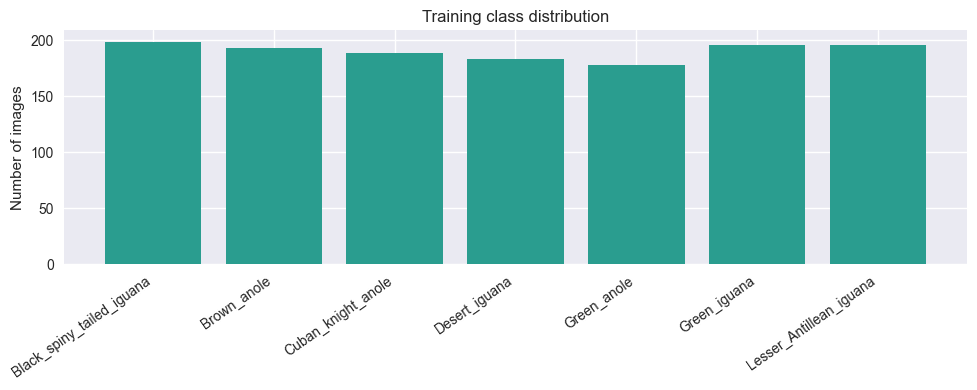

train.csv columns: ['id', 'label', 'path', 'class_name']
test.csv columns: ['id', 'path']
sample_submission columns: ['id', 'label']


In [20]:
label_counts = train_df["label"].value_counts().sort_index()
class_distribution = pd.DataFrame(
    {
        "label": label_counts.index,
        "class_name": [label_to_class[i] for i in label_counts.index],
        "count": label_counts.values,
        "share_pct": (100 * label_counts.values / len(train_df)).round(2),
    }
)
display(class_distribution)

plt.figure(figsize=(10, 4))
plt.bar(class_distribution["class_name"], class_distribution["count"], color="#2a9d8f")
plt.xticks(rotation=35, ha="right")
plt.ylabel("Number of images")
plt.title("Training class distribution")
plt.tight_layout()
plt.show()

print("train.csv columns:", train_df.columns.tolist())
print("test.csv columns:", test_df.columns.tolist())
print("sample_submission columns:", pd.read_csv(SAMPLE_SUBMISSION).columns.tolist())

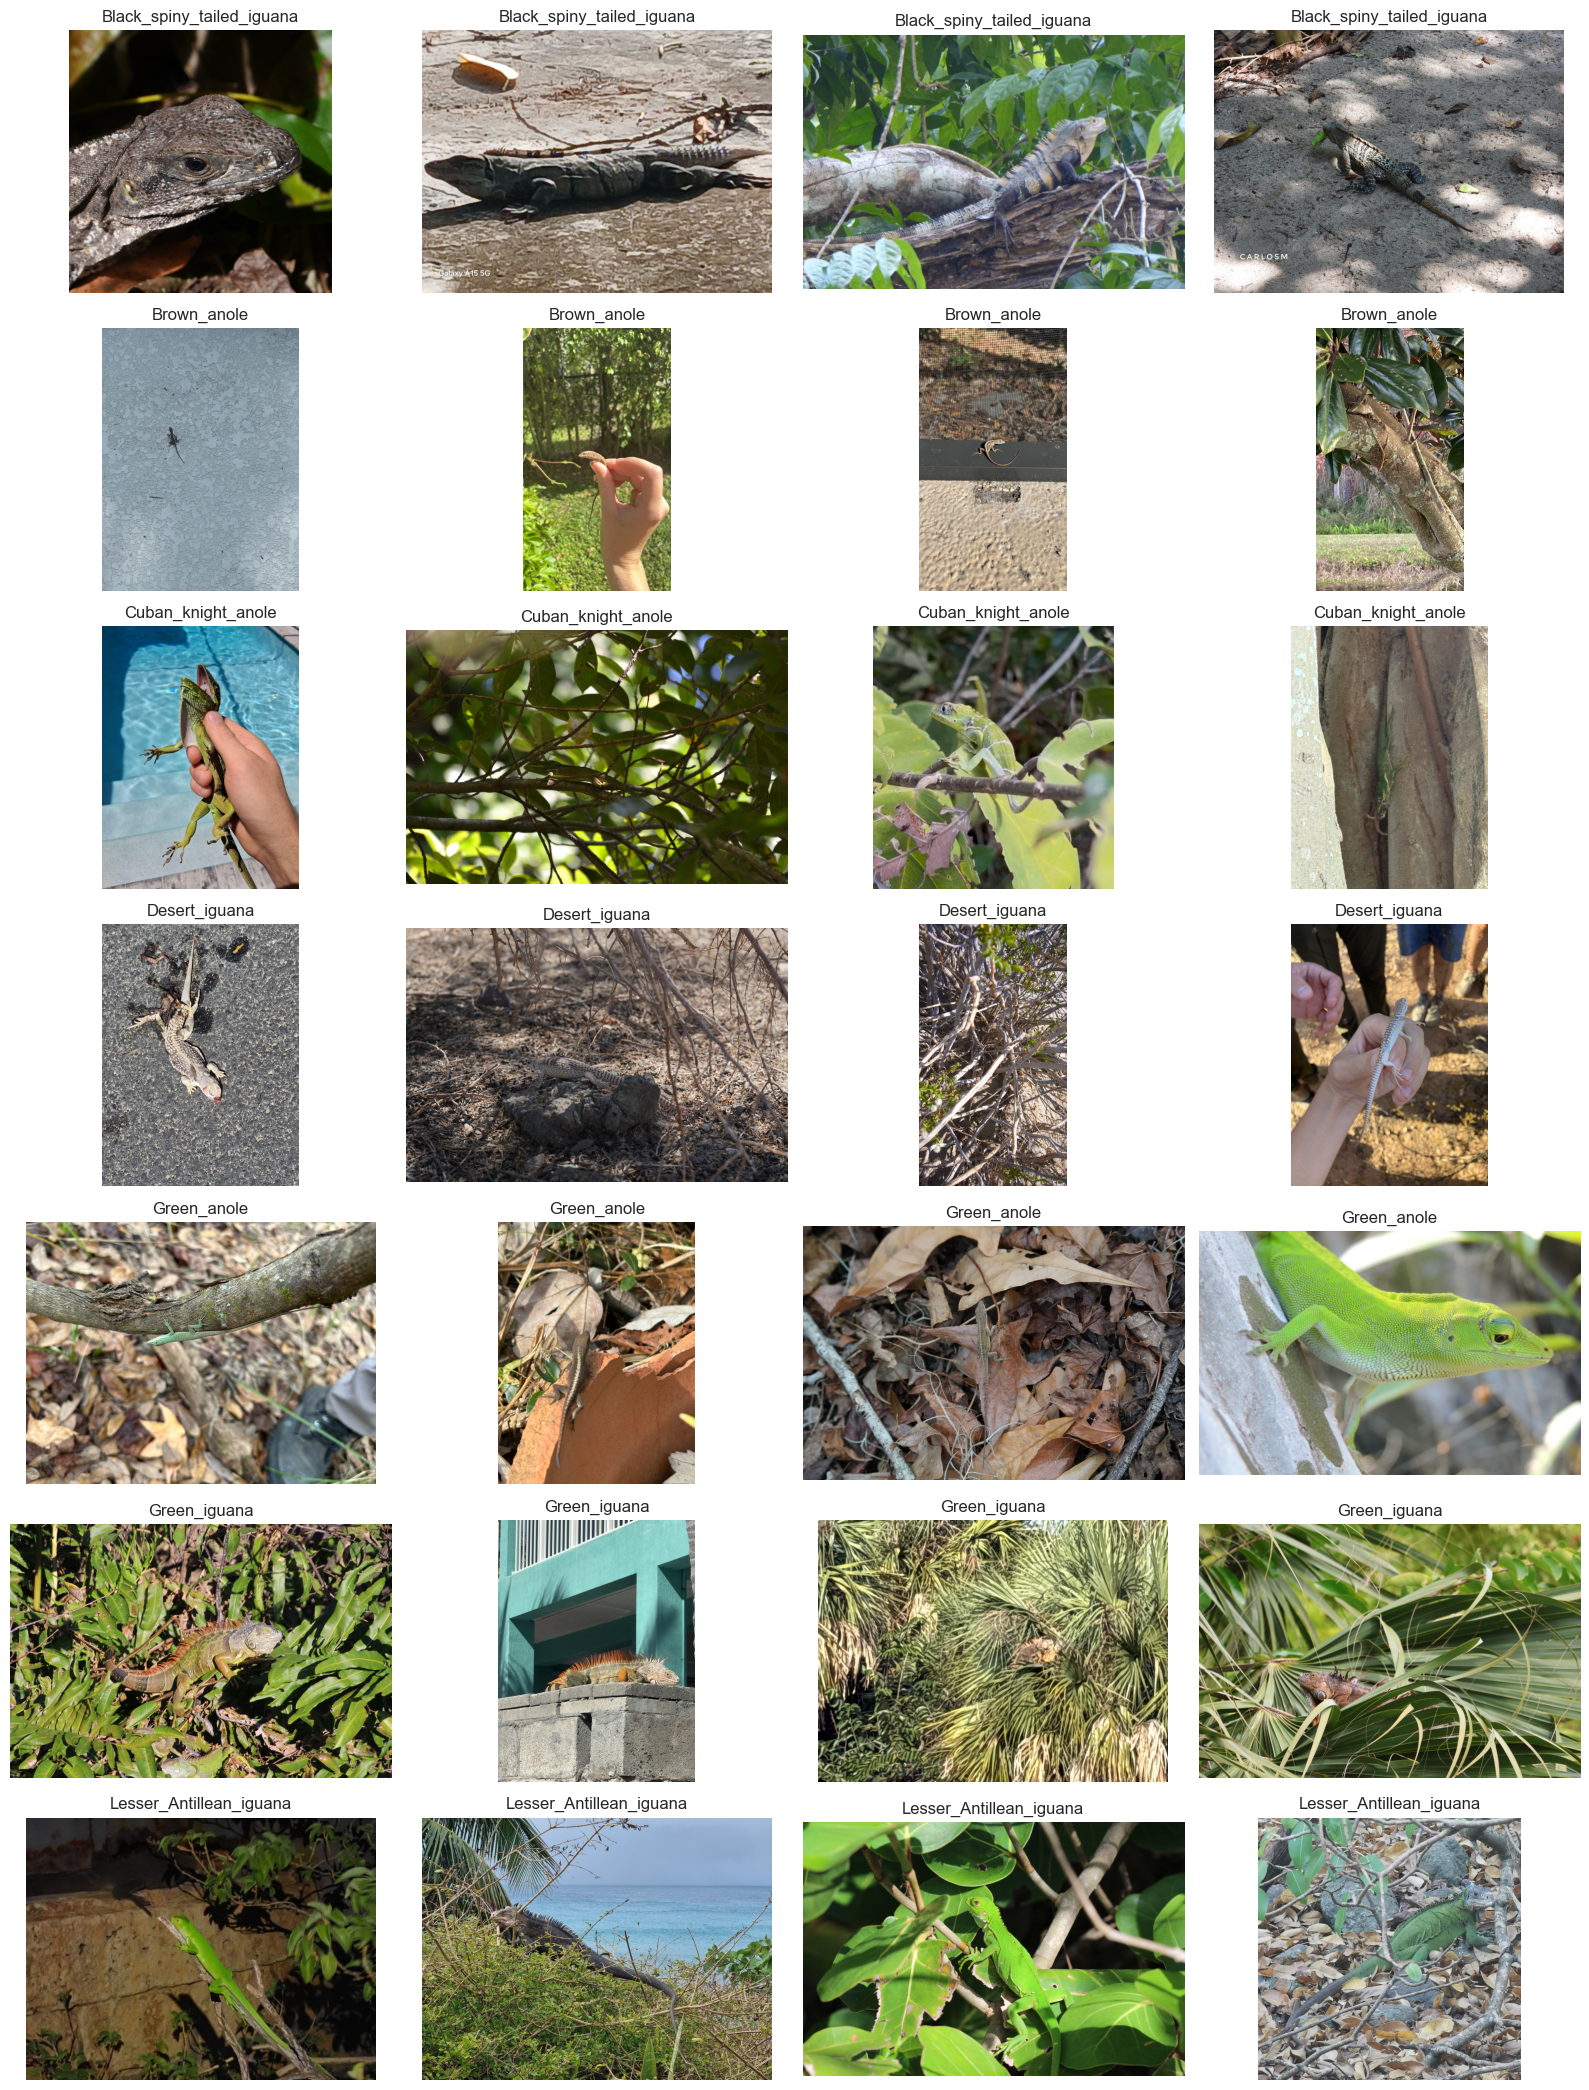

In [21]:
def show_class_examples(df: pd.DataFrame, n_per_class: int = 4) -> None:
    fig, axes = plt.subplots(num_classes, n_per_class, figsize=(4 * n_per_class, 3 * num_classes))
    axes = np.atleast_2d(axes)
    for row_idx, label in enumerate(sorted(label_to_class)):
        subset = df[df["label"] == label].sample(n_per_class, random_state=SEED)
        for col_idx, (_, row) in enumerate(subset.reset_index(drop=True).iterrows()):
            with Image.open(row["path"]) as img:
                axes[row_idx, col_idx].imshow(ImageOps.exif_transpose(img).convert("RGB"))
            axes[row_idx, col_idx].set_title(label_to_class[label])
            axes[row_idx, col_idx].axis("off")
    plt.tight_layout()
    plt.show()

show_class_examples(train_df, n_per_class=4)

,split,n_images,width_min,width_median,width_max,height_min,height_median,height_max,brightness_median
0,train,1334,282,1536,2048,293,2020,2048,119.57
1,test,326,395,1536,2048,499,2048,2048,120.76


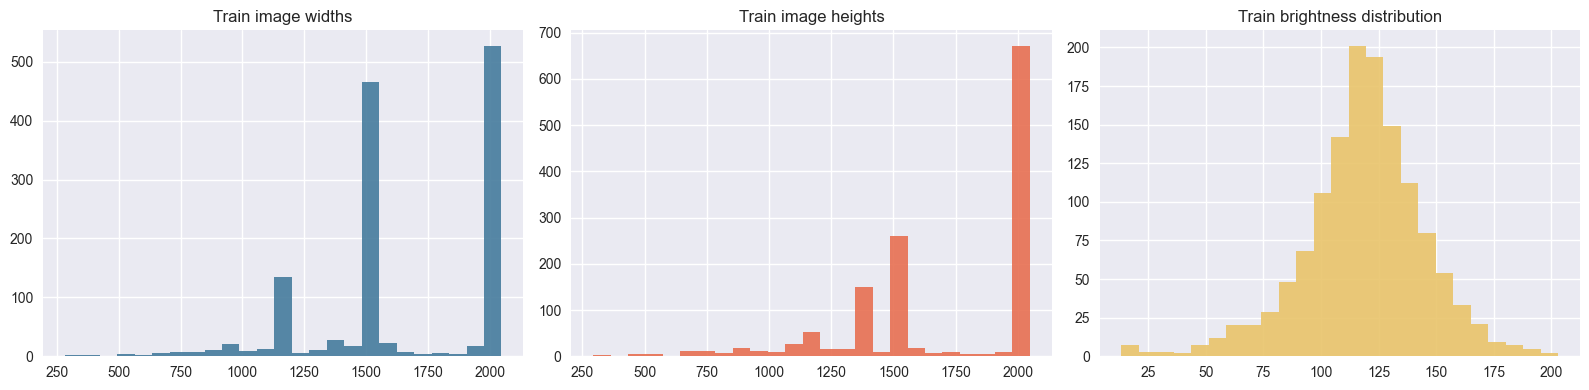

In [22]:
def collect_image_stats(paths: list[Path]) -> pd.DataFrame:
    records = []
    for path in paths:
        with Image.open(path) as img:
            rgb = ImageOps.exif_transpose(img).convert("RGB")
            gray = np.asarray(rgb.convert("L"))
            width, height = rgb.size
        records.append(
            {
                "path": path,
                "width": width,
                "height": height,
                "aspect_ratio": width / height,
                "brightness": float(gray.mean()),
                "blur_laplacian_var": float(cv2.Laplacian(gray, cv2.CV_64F).var()),
            }
        )
    return pd.DataFrame(records)

train_stats = collect_image_stats(train_df["path"].tolist())
test_stats = collect_image_stats(test_df["path"].tolist())

eda_summary = pd.DataFrame(
    {
        "split": ["train", "test"],
        "n_images": [len(train_stats), len(test_stats)],
        "width_min": [train_stats["width"].min(), test_stats["width"].min()],
        "width_median": [int(train_stats["width"].median()), int(test_stats["width"].median())],
        "width_max": [train_stats["width"].max(), test_stats["width"].max()],
        "height_min": [train_stats["height"].min(), test_stats["height"].min()],
        "height_median": [int(train_stats["height"].median()), int(test_stats["height"].median())],
        "height_max": [train_stats["height"].max(), test_stats["height"].max()],
        "brightness_median": [round(train_stats["brightness"].median(), 2), round(test_stats["brightness"].median(), 2)],
    }
)
display(eda_summary)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(train_stats["width"], bins=25, color="#457b9d", alpha=0.9)
axes[0].set_title("Train image widths")
axes[1].hist(train_stats["height"], bins=25, color="#e76f51", alpha=0.9)
axes[1].set_title("Train image heights")
axes[2].hist(train_stats["brightness"], bins=25, color="#e9c46a", alpha=0.9)
axes[2].set_title("Train brightness distribution")
plt.tight_layout()
plt.show()

In [23]:
def average_hash(path: Path, hash_size: int = 16) -> str:
    with Image.open(path) as img:
        gray = ImageOps.exif_transpose(img).convert("L").resize(
            (hash_size, hash_size),
            Image.Resampling.BILINEAR,
        )
        arr = np.asarray(gray, dtype=np.float32)
    return "".join("1" if pixel > arr.mean() else "0" for pixel in arr.flatten())

train_df["hash_group"] = train_df["path"].map(average_hash)

hash_group_sizes = train_df.groupby("hash_group").size().sort_values(ascending=False)
duplicate_groups = hash_group_sizes[hash_group_sizes > 1]

print("Approximate duplicate groups:", len(duplicate_groups))
if len(duplicate_groups) > 0:
    print("Largest duplicate group size:", int(duplicate_groups.iloc[0]))
    duplicate_preview = (
        train_df[train_df["hash_group"].isin(duplicate_groups.index[:5])]
        .sort_values(["hash_group", "class_name", "id"])
        [["id", "class_name", "hash_group"]]
        .reset_index(drop=True)
    )
    display(duplicate_preview.head(20))

Approximate duplicate groups: 121
Largest duplicate group size: 3


,id,class_name,hash_group
0,Black_spiny-tailed_iguana_Black_spiny-tailed_i...,Black_spiny_tailed_iguana,0000000000000000000000000110000000000000001011...
1,Black_spiny-tailed_iguana_Black_spiny-tailed_i...,Black_spiny_tailed_iguana,0000000000000000000000000110000000000000001011...
2,Black_spiny-tailed_iguana_Ctenosaura_similis_5...,Black_spiny_tailed_iguana,0000000000000000000000000110000000000000001011...
3,Cuban_knight_anole_Anolis_equestris_9.jpg,Cuban_knight_anole,0000000000000000110001000000000001110000000000...
4,Cuban_knight_anole_Cuban_knight_anole_209.jpg,Cuban_knight_anole,0000000000000000110001000000000001110000000000...
5,Cuban_knight_anole_Cuban_knight_anole_9.jpg,Cuban_knight_anole,0000000000000000110001000000000001110000000000...
6,Lesser_Antillean_iguana_Iguana_delicatissima_1...,Lesser_Antillean_iguana,0000001111111000000111111111100000011001111100...
7,Lesser_Antillean_iguana_Lesser_Antillean_iguan...,Lesser_Antillean_iguana,0000001111111000000111111111100000011001111100...
8,Lesser_Antillean_iguana_Lesser_Antillean_iguan...,Lesser_Antillean_iguana,0000001111111000000111111111100000011001111100...
9,Cuban_knight_anole_Anolis_equestris_12.jpg,Cuban_knight_anole,0000111111111000000011111111100000111111111111...


In [24]:
def text_overlay_score(path: Path) -> int:
    image = cv2.imread(str(path))
    if image is None:
        return -1
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    gray = cv2.resize(gray, (512, 512))
    gradient = cv2.morphologyEx(gray, cv2.MORPH_GRADIENT, np.ones((3, 3), np.uint8))
    _, thresh = cv2.threshold(gradient, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (11, 3))
    merged = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=1)
    contours, _ = cv2.findContours(merged, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    candidates = 0
    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)
        area = w * h
        aspect_ratio = w / max(h, 1)
        if 60 <= area <= 6000 and aspect_ratio > 1.8 and h < 70:
            candidates += 1
    return candidates

sample_parts = []
for _, subset in train_df.groupby("label"):
    sample_parts.append(subset.sample(min(len(subset), 25), random_state=SEED))
text_check_df = pd.concat(sample_parts).reset_index(drop=True)
text_check_df["text_overlay_score"] = text_check_df["path"].map(text_overlay_score)

ocr_available = False
pytesseract = None
try:
    import pytesseract  # type: ignore
    ocr_available = shutil.which("tesseract") is not None
except Exception:
    pytesseract = None

if ocr_available:
    def extract_text(path: Path) -> str:
        text = pytesseract.image_to_string(str(path), config="--psm 11")
        return " ".join(text.split())

    text_check_df["ocr_text"] = text_check_df["path"].map(extract_text)
    text_check_df["has_ocr_text"] = text_check_df["ocr_text"].str.len() >= 4
    display(
        text_check_df.sort_values(
            ["has_ocr_text", "text_overlay_score"],
            ascending=[False, False],
        )[["id", "class_name", "text_overlay_score", "ocr_text"]].head(15)
    )
else:
    print("pytesseract / Tesseract not available in this environment.")
    print("Fallback: OpenCV text-overlay heuristic only.")
    display(
        text_check_df.sort_values("text_overlay_score", ascending=False)[
            ["id", "class_name", "text_overlay_score"]
        ].head(15)
    )

pytesseract / Tesseract not available in this environment.
Fallback: OpenCV text-overlay heuristic only.


,id,class_name,text_overlay_score
143,Green_iguana_Green_iguana_183.jpg,Green_iguana,83
71,Cuban_knight_anole_Cuban_knight_anole_55.jpg,Cuban_knight_anole,65
117,Green_anole_Green_anole_192.jpg,Green_anole,61
137,Green_iguana_Green_iguana_80.jpg,Green_iguana,54
27,Brown_anole_Brown_anole_16.jpg,Brown_anole,52
96,Desert_iguana_Desert_iguana_46.jpg,Desert_iguana,52
136,Green_iguana_Green_iguana_117.jpg,Green_iguana,44
14,Black_spiny-tailed_iguana_Black_spiny-tailed_i...,Black_spiny_tailed_iguana,40
20,Black_spiny-tailed_iguana_Black_spiny-tailed_i...,Black_spiny_tailed_iguana,39
120,Green_anole_Green_anole_119.jpg,Green_anole,38


## 2. Validation Strategy

A random split can be misleading when the dataset contains duplicate or near-duplicate images.  
To reduce leakage, we first create image hash groups and then do a **stratified group split**:

- class balance stays similar in train and validation
- images with the same hash group stay together
- validation macro-F1 becomes more trustworthy

In [25]:
def stratified_group_split(df: pd.DataFrame, val_fraction: float = 0.2, seed: int = 42) -> tuple[pd.DataFrame, pd.DataFrame]:
    rng = np.random.default_rng(seed)
    target_total = int(round(len(df) * val_fraction))
    target_per_label = df["label"].value_counts().sort_index() * val_fraction

    group_rows = []
    for hash_group, subset in df.groupby("hash_group"):
        label_counts = subset["label"].value_counts().sort_index()
        row = {
            "hash_group": hash_group,
            "group_size": len(subset),
        }
        for label in sorted(label_to_class):
            row[f"label_{label}"] = int(label_counts.get(label, 0))
        group_rows.append(row)

    group_df = pd.DataFrame(group_rows)
    group_df = group_df.sample(frac=1.0, random_state=seed).sort_values("group_size", ascending=False).reset_index(drop=True)

    val_groups = []
    val_total = 0
    current_counts = pd.Series(0.0, index=target_per_label.index)

    for row in group_df.itertuples(index=False):
        row_counts = pd.Series(
            {label: getattr(row, f"label_{label}") for label in target_per_label.index},
            dtype=float,
        )

        remaining_deficit = (target_per_label - current_counts).clip(lower=0)
        group_fills_needed_labels = float((np.minimum(row_counts, remaining_deficit)).sum())
        group_excess = float((row_counts - remaining_deficit).clip(lower=0).sum())

        should_add = False
        if val_total < target_total and group_fills_needed_labels > 0:
            should_add = True
        elif val_total + row.group_size <= target_total and len(val_groups) == 0:
            should_add = True

        if should_add:
            val_groups.append(row.hash_group)
            current_counts += row_counts
            val_total += int(row.group_size)

    if not val_groups:
        val_groups = group_df.head(1)["hash_group"].tolist()

    mask = df["hash_group"].isin(val_groups)
    train_split = df[~mask].sample(frac=1.0, random_state=seed).reset_index(drop=True)
    val_split = df[mask].sample(frac=1.0, random_state=seed).reset_index(drop=True)
    return train_split, val_split

if "hash_group" not in train_df.columns:
    train_df["hash_group"] = train_df["path"].map(average_hash)

train_split, val_split = stratified_group_split(train_df, val_fraction=VAL_FRACTION, seed=SEED)

print("Train split shape:", train_split.shape)
print("Validation split shape:", val_split.shape)
print("Hash overlap:", len(set(train_split["hash_group"]) & set(val_split["hash_group"])))

split_summary = pd.DataFrame(
    {
        "class_name": class_names,
        "train_count": train_split["label"].value_counts().sort_index().values,
        "val_count": val_split["label"].value_counts().sort_index().values,
    }
)
split_summary["val_share_pct"] = (100 * split_summary["val_count"] / (split_summary["train_count"] + split_summary["val_count"])).round(2)
display(split_summary)

Train split shape: (1067, 5)
Validation split shape: (267, 5)
Hash overlap: 0


,class_name,train_count,val_count,val_share_pct
0,Black_spiny_tailed_iguana,159,40,20.10
1,Brown_anole,154,39,20.21
2,Cuban_knight_anole,150,39,20.63
3,Desert_iguana,146,37,20.22
4,Green_anole,144,34,19.10
5,Green_iguana,159,37,18.88
6,Lesser_Antillean_iguana,155,41,20.92


## 3. TensorFlow / Keras Input Pipeline

We keep the pipeline fully inside TensorFlow:

- file paths are read from the CSV-driven dataframe
- images are decoded and resized on the fly
- augmentation is done with Keras preprocessing layers
- `tf.data` takes care of batching and prefetching

In [26]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.08),
        layers.RandomZoom(0.15),
        layers.RandomContrast(0.15),
        layers.RandomTranslation(0.05, 0.05),
    ],
    name="augmentation",
)

@tf.autograph.experimental.do_not_convert
def decode_image(path: tf.Tensor, label: tf.Tensor | None = None):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE, method=tf.image.ResizeMethod.BICUBIC)
    image = tf.cast(image, tf.float32)
    image = tf.clip_by_value(image, 0.0, 255.0)
    if label is None:
        return image
    return image, tf.cast(label, tf.int32)

def make_labeled_dataset(df: pd.DataFrame, training: bool = False) -> tf.data.Dataset:
    dataset = tf.data.Dataset.from_tensor_slices(
        (df["path"].astype(str).values, df["label"].values.astype("int32"))
    )
    if training:
        dataset = dataset.shuffle(len(df), seed=SEED, reshuffle_each_iteration=True)
    dataset = dataset.map(decode_image, num_parallel_calls=AUTOTUNE)
    dataset = dataset.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return dataset

def make_test_dataset(df: pd.DataFrame) -> tf.data.Dataset:
    dataset = tf.data.Dataset.from_tensor_slices(df["path"].astype(str).values)
    dataset = dataset.map(decode_image, num_parallel_calls=AUTOTUNE)
    dataset = dataset.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return dataset

train_ds = make_labeled_dataset(train_split, training=True)
val_ds = make_labeled_dataset(val_split, training=False)
test_ds = make_test_dataset(test_df)

for images, labels in train_ds.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)

Image batch shape: (24, 260, 260, 3)
Label batch shape: (24,)


## 4. Transfer Learning Model

We use an ImageNet-pretrained backbone as a feature extractor, then fine-tune the top part later.

Training happens in two stages:
1. freeze the backbone and train only the classification head
2. unfreeze the top layers and continue with a much smaller learning rate

In [27]:
def build_transfer_model(
    input_shape: tuple[int, int, int] = IMG_SIZE + (3,),
    num_classes: int = 7,
    dropout_rate: float = 0.35,
    weights: str | None = "imagenet",
) -> tuple[keras.Model, keras.Model]:
    try:
        backbone = keras.applications.EfficientNetB0(
            include_top=False,
            weights=weights,
            input_shape=input_shape,
        )
        print("Loaded EfficientNetB0 with ImageNet weights.")
    except Exception as exc:
        print(f"Could not load pretrained weights ({exc}). Falling back to random initialization.")
        backbone = keras.applications.EfficientNetB0(
            include_top=False,
            weights=None,
            input_shape=input_shape,
        )

    backbone.trainable = False

    inputs = keras.Input(shape=input_shape)
    x = data_augmentation(inputs)
    x = keras.applications.efficientnet.preprocess_input(x)
    x = backbone(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(num_classes, activation="softmax", dtype="float32")(x)

    model = keras.Model(inputs, outputs, name="lizard_classifier")
    return model, backbone

def make_class_weights(labels: pd.Series) -> dict[int, float]:
    counts = labels.value_counts().to_dict()
    total = len(labels)
    n_classes = len(counts)
    return {int(label): total / (n_classes * count) for label, count in counts.items()}

model, backbone = build_transfer_model(num_classes=num_classes)
class_weights = make_class_weights(train_split["label"])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=3e-4),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)

checkpoint_path = ROOT / "best_lizard_model.keras"
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=checkpoint_path,
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        verbose=1,
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=4,
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-6,
        verbose=1,
    ),
]

model.summary()
print("Class weights:", class_weights)

Loaded EfficientNetB0 with ImageNet weights.


Model: "lizard_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 260, 260, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 260, 260, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 9, 9, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         8,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,063,658 (15.50 MB)

 Trainable params: 11,527 (45.03 KB)

 Non-trainable params: 4,052,131 (15.46 MB)

Class weights: {0: 0.958670260557053, 5: 0.958670260557053, 6: 0.9834101382488479, 1: 0.9897959183673469, 2: 1.016190476190476, 3: 1.044031311154599, 4: 1.058531746031746}


In [28]:
history_head = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=INITIAL_EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/8
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 490ms/step - accuracy: 0.1706 - loss: 2.8177
Epoch 1: val_loss improved from None to 1.72952, saving model to C:\TM\2e_jaar\Semester_2\AI\AI-Lizard-Prediction-Challenge\best_lizard_model.keras

Epoch 1: finished saving model to C:\TM\2e_jaar\Semester_2\AI\AI-Lizard-Prediction-Challenge\best_lizard_model.keras
45/45 ━━━━━━━━━━━━━━━━━━━━ 42s 683ms/step - accuracy: 0.2156 - loss: 2.5814 - val_accuracy: 0.3745 - val_loss: 1.7295 - learning_rate: 3.0000e-04
Epoch 2/8
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 494ms/step - accuracy: 0.2939 - loss: 2.0594
Epoch 2: val_loss improved from 1.72952 to 1.52958, saving model to C:\TM\2e_jaar\Semester_2\AI\AI-Lizard-Prediction-Challenge\best_lizard_model.keras

Epoch 2: finished saving model to C:\TM\2e_jaar\Semester_2\AI\AI-Lizard-Prediction-Challenge\best_lizard_model.keras
45/45 ━━━━━━━━━━━━━━━━━━━━ 29s 629ms/step - accuracy: 0.3327 - loss: 1.9655 - val_accuracy: 0.4270 - val_loss: 1.5296 - learning_rate: 3.0000e-04
Epo

In [29]:
def unfreeze_top_layers(backbone_model: keras.Model, n_layers: int = 40) -> None:
    backbone_model.trainable = True
    for layer in backbone_model.layers[:-n_layers]:
        layer.trainable = False
    for layer in backbone_model.layers:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False

unfreeze_top_layers(backbone, n_layers=FINE_TUNE_LAYERS)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=3e-5),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINE_TUNE_EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1,
)

model = keras.models.load_model(checkpoint_path)
print("Reloaded best validation checkpoint from:", checkpoint_path)

Epoch 1/12
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 579ms/step - accuracy: 0.5647 - loss: 1.2304
Epoch 1: val_loss improved from 1.08613 to 1.07074, saving model to C:\TM\2e_jaar\Semester_2\AI\AI-Lizard-Prediction-Challenge\best_lizard_model.keras

Epoch 1: finished saving model to C:\TM\2e_jaar\Semester_2\AI\AI-Lizard-Prediction-Challenge\best_lizard_model.keras
45/45 ━━━━━━━━━━━━━━━━━━━━ 49s 774ms/step - accuracy: 0.5689 - loss: 1.2245 - val_accuracy: 0.6217 - val_loss: 1.0707 - learning_rate: 3.0000e-05
Epoch 2/12
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 562ms/step - accuracy: 0.5636 - loss: 1.2011
Epoch 2: val_loss improved from 1.07074 to 1.06320, saving model to C:\TM\2e_jaar\Semester_2\AI\AI-Lizard-Prediction-Challenge\best_lizard_model.keras

Epoch 2: finished saving model to C:\TM\2e_jaar\Semester_2\AI\AI-Lizard-Prediction-Challenge\best_lizard_model.keras
45/45 ━━━━━━━━━━━━━━━━━━━━ 32s 701ms/step - accuracy: 0.5736 - loss: 1.1999 - val_accuracy: 0.6067 - val_loss: 1.0632 - learning_rate: 3.0000e-0

,accuracy,loss,val_accuracy,val_loss,learning_rate,epoch
15,0.679475,0.903189,0.636704,1.002939,0.00003,16
16,0.686036,0.860603,0.644195,0.992878,0.00003,17
17,0.701031,0.836597,0.666667,0.976976,0.00003,18
18,0.716963,0.791861,0.651685,0.983088,0.00003,19
19,0.735708,0.732191,0.629214,0.996611,0.00003,20


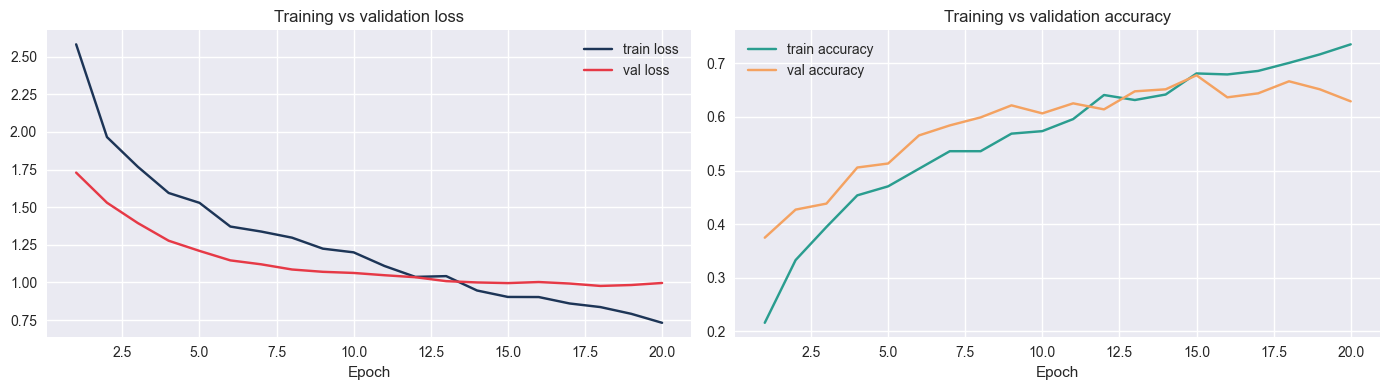

In [30]:
def combine_histories(*histories: keras.callbacks.History) -> pd.DataFrame:
    rows = []
    epoch_offset = 0
    for history in histories:
        history_frame = pd.DataFrame(history.history)
        history_frame["epoch"] = np.arange(len(history_frame)) + epoch_offset + 1
        rows.append(history_frame)
        epoch_offset += len(history_frame)
    return pd.concat(rows, ignore_index=True)

history_df = combine_histories(history_head, history_fine)
display(history_df.tail())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history_df["epoch"], history_df["loss"], label="train loss", color="#1d3557")
axes[0].plot(history_df["epoch"], history_df["val_loss"], label="val loss", color="#e63946")
axes[0].set_title("Training vs validation loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history_df["epoch"], history_df["accuracy"], label="train accuracy", color="#2a9d8f")
axes[1].plot(history_df["epoch"], history_df["val_accuracy"], label="val accuracy", color="#f4a261")
axes[1].set_title("Training vs validation accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Evaluation

The official metric is **macro-F1**, so we evaluate with:

- validation accuracy
- confusion matrix
- per-class precision, recall and F1
- a short visual error analysis on misclassified examples

In [31]:
def metrics_from_confusion_matrix(cm: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray, float]:
    true_positives = np.diag(cm).astype(np.float64)
    precision = np.divide(
        true_positives,
        cm.sum(axis=0),
        out=np.zeros_like(true_positives),
        where=cm.sum(axis=0) != 0,
    )
    recall = np.divide(
        true_positives,
        cm.sum(axis=1),
        out=np.zeros_like(true_positives),
        where=cm.sum(axis=1) != 0,
    )
    f1 = np.divide(
        2 * precision * recall,
        precision + recall,
        out=np.zeros_like(true_positives),
        where=(precision + recall) != 0,
    )
    return precision, recall, f1, float(f1.mean())

val_probabilities = model.predict(val_ds, verbose=0)
val_predictions = val_probabilities.argmax(axis=1)
val_targets = val_split["label"].to_numpy()

confusion = tf.math.confusion_matrix(
    val_targets,
    val_predictions,
    num_classes=num_classes,
).numpy()

precision, recall, f1_per_class, macro_f1 = metrics_from_confusion_matrix(confusion)
val_accuracy = float((val_predictions == val_targets).mean())

evaluation_table = pd.DataFrame(
    {
        "class_name": class_names,
        "precision": np.round(precision, 4),
        "recall": np.round(recall, 4),
        "f1": np.round(f1_per_class, 4),
        "support": confusion.sum(axis=1),
    }
)

print(f"Validation accuracy: {val_accuracy:.4f}")
print(f"Validation macro-F1: {macro_f1:.4f}")
display(evaluation_table)

Validation accuracy: 0.6667
Validation macro-F1: 0.6609


,class_name,precision,recall,f1,support
0,Black_spiny_tailed_iguana,0.7949,0.7750,0.7848,40
1,Brown_anole,0.6923,0.6923,0.6923,39
2,Cuban_knight_anole,0.5333,0.6154,0.5714,39
3,Desert_iguana,0.9250,1.0000,0.9610,37
4,Green_anole,0.4359,0.5000,0.4658,34
5,Green_iguana,0.5769,0.4054,0.4762,37
6,Lesser_Antillean_iguana,0.6923,0.6585,0.6750,41


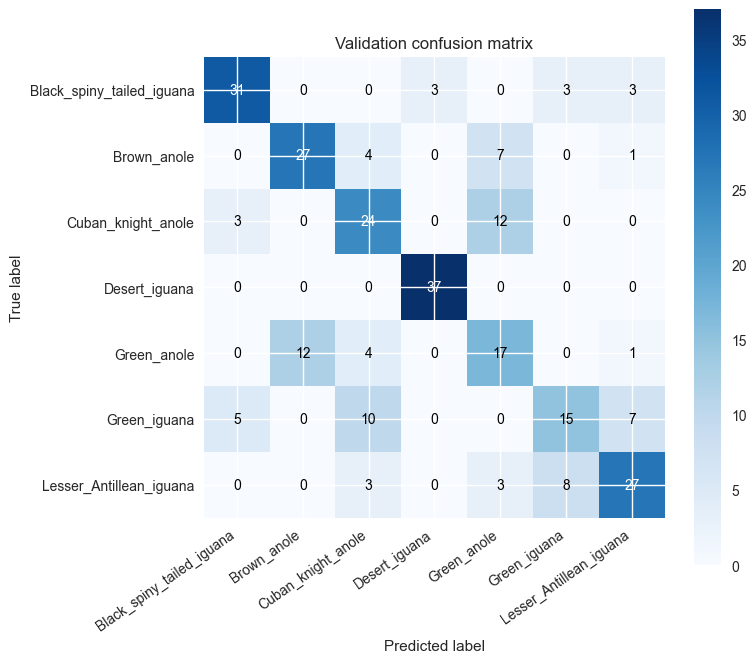

In [32]:
def plot_confusion_matrix(cm: np.ndarray, labels: list[str]) -> None:
    plt.figure(figsize=(8, 7))
    plt.imshow(cm, cmap="Blues")
    plt.title("Validation confusion matrix")
    plt.colorbar()
    tick_positions = np.arange(len(labels))
    plt.xticks(tick_positions, labels, rotation=35, ha="right")
    plt.yticks(tick_positions, labels)

    threshold = cm.max() / 2 if cm.max() > 0 else 0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            color = "white" if cm[i, j] > threshold else "black"
            plt.text(j, i, int(cm[i, j]), ha="center", va="center", color=color)

    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(confusion, class_names)

,id,class_name,pred_class_name,confidence
1,Brown_anole_Anolis_carolinensis_17.jpg,Brown_anole,Green_anole,0.998588
71,Green_anole_Green_anole_8.jpg,Green_anole,Brown_anole,0.983559
129,Brown_anole_Anolis_carolinensis_3.jpg,Brown_anole,Green_anole,0.980681
225,Brown_anole_Anolis_carolinensis_20.jpg,Brown_anole,Green_anole,0.956475
5,Green_iguana_Iguana_iguana_3.jpg,Green_iguana,Lesser_Antillean_iguana,0.898524
102,Green_iguana_Green_iguana_3.jpg,Green_iguana,Lesser_Antillean_iguana,0.898524
177,Green_iguana_Green_iguana_218.jpg,Green_iguana,Lesser_Antillean_iguana,0.898524
42,Green_anole_Green_anole_2.jpg,Green_anole,Brown_anole,0.866433
216,Green_anole_Green_anole_202.jpg,Green_anole,Brown_anole,0.866433
135,Green_anole_Green_anole_206.jpg,Green_anole,Brown_anole,0.849868


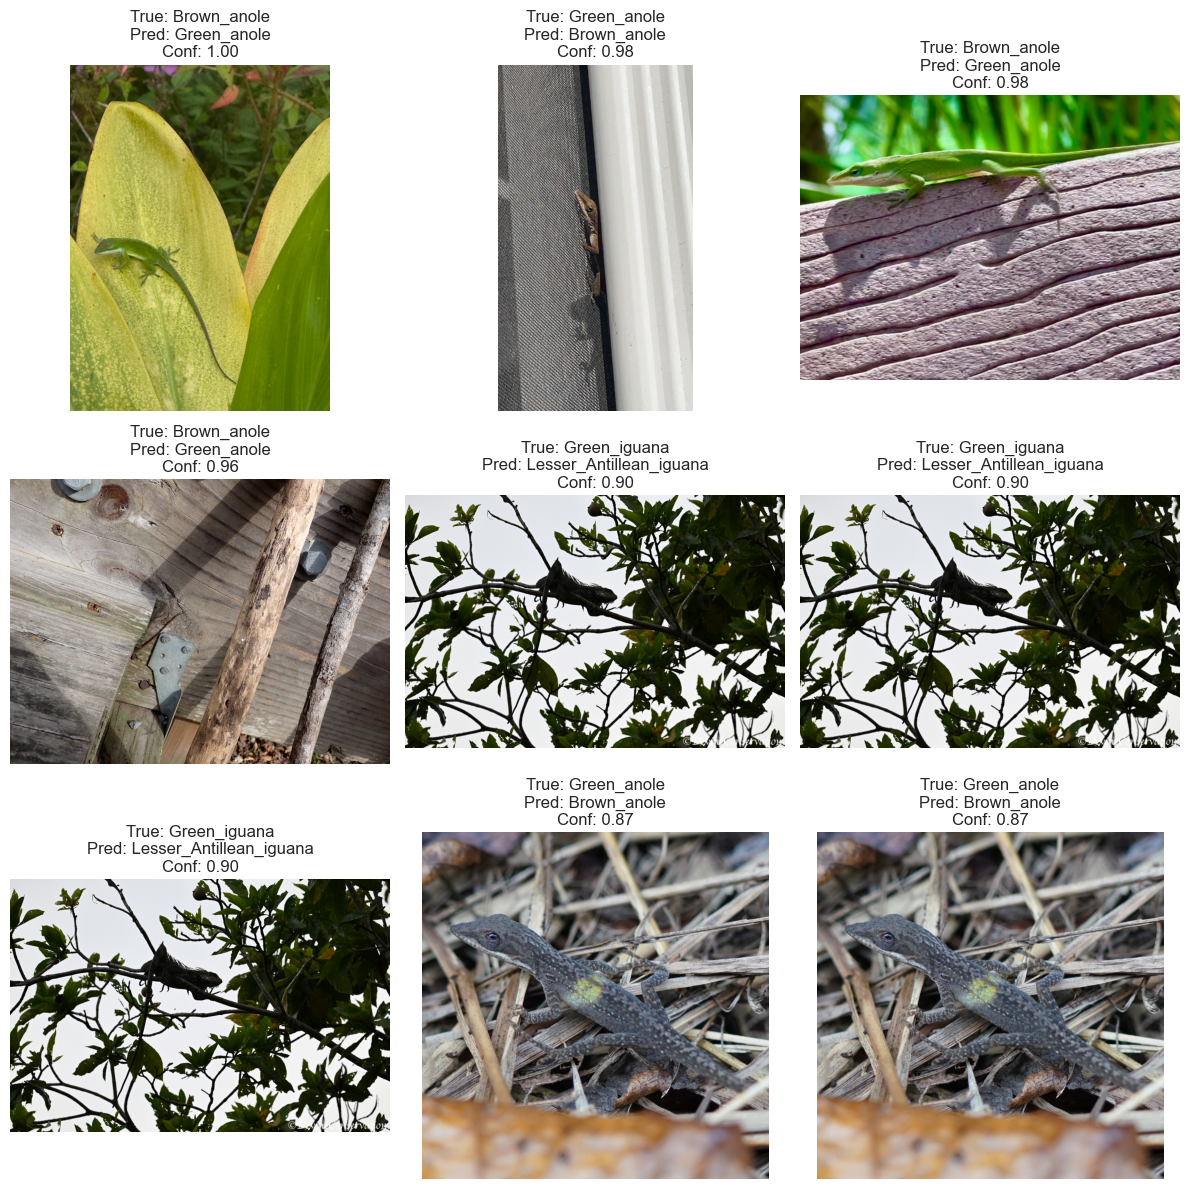

In [33]:
error_df = val_split.copy()
error_df["pred_label"] = val_predictions
error_df["pred_class_name"] = error_df["pred_label"].map(label_to_class)
error_df["confidence"] = val_probabilities.max(axis=1)
misclassified = error_df[error_df["label"] != error_df["pred_label"]].sort_values("confidence", ascending=False)

display(misclassified[["id", "class_name", "pred_class_name", "confidence"]].head(10))

n_examples = min(9, len(misclassified))
if n_examples > 0:
    fig, axes = plt.subplots(math.ceil(n_examples / 3), 3, figsize=(12, 4 * math.ceil(n_examples / 3)))
    axes = np.array(axes).reshape(-1)
    for ax in axes[n_examples:]:
        ax.axis("off")

    for ax, (_, row) in zip(axes, misclassified.head(n_examples).iterrows()):
        with Image.open(row["path"]) as img:
            ax.imshow(ImageOps.exif_transpose(img).convert("RGB"))
        ax.set_title(
            f"True: {row['class_name']}\nPred: {row['pred_class_name']}\nConf: {row['confidence']:.2f}"
        )
        ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("No misclassified validation images in this run.")

## 6. Submission File

To squeeze a little more performance out of the final model, we optionally use a very simple form of test-time augmentation:

- original test image
- horizontally flipped test image

The predicted probabilities are averaged before taking the final class label.

In [34]:
def horizontal_flip_dataset(dataset: tf.data.Dataset) -> tf.data.Dataset:
    return dataset.map(
        lambda images: tf.image.flip_left_right(images),
        num_parallel_calls=AUTOTUNE,
    ).prefetch(AUTOTUNE)

if USE_TTA:
    test_probs_base = model.predict(test_ds, verbose=0)
    test_probs_flip = model.predict(horizontal_flip_dataset(test_ds), verbose=0)
    test_probabilities = (test_probs_base + test_probs_flip) / 2.0
else:
    test_probabilities = model.predict(test_ds, verbose=0)

test_predictions = test_probabilities.argmax(axis=1).astype(int)

submission_df = pd.DataFrame(
    {
        "ID": test_df["id"].astype(int),
        "TARGET": test_predictions,
    }
)
submission_path = ROOT / "submission_transfer_learning.csv"
submission_df.to_csv(submission_path, index=False)

print("Saved submission to:", submission_path)
display(submission_df.head())

Saved submission to: C:\TM\2e_jaar\Semester_2\AI\AI-Lizard-Prediction-Challenge\submission_transfer_learning.csv


,ID,TARGET
0,1,0
1,2,5
2,3,2
3,4,5
4,5,1


## 7. Results Discussion

Replace the placeholders below after your final training run:

- **Best validation accuracy:** `<fill in>`
- **Best validation macro-F1:** `<fill in>`
- **Main confusion pairs:** `<fill in>`
- **What helped most:** duplicate-aware split, augmentation, staged fine-tuning, TTA

In practice, the hardest errors are expected between visually similar green/brown species and between iguana variants with comparable body shape or background context.

## 8. GenAI Reflection

GenAI was used as a support tool during the project, not as a replacement for understanding.

### How it helped
- structure the notebook into a clear, defendable workflow
- suggest extra validation ideas such as duplicate checks and text-overlay screening
- help brainstorm transfer-learning improvements and training callbacks
- improve the wording of explanations and markdown sections

### What we still validated ourselves
- the label mapping between CSV and folders
- whether the split strategy avoids duplicate leakage
- whether the model architecture and training settings are appropriate
- whether the exported submission matches the required format

### Important limitation
Suggestions from GenAI can be useful, but they still need human verification.  
For that reason, every technical choice in this notebook was checked against the dataset, the course material, and the observed validation behaviour.